# Meu Data Set de treinos 🏋🏻‍♂️
**Inicio do primeiro registro de treino 🚶🏻‍♂️‍➡️:**     
    *13 Mar 2023, 14:52*<br>
**Atual treino 🏃🏻‍♂️‍➡️:**    
    *30 Abr 2026, 21:27*<br>

In [147]:
import pandas as pd

## Investigando a base de dados

### Abaixo podemos ver algumas informações da nossa base de dados.

In [148]:
arquivo = 'workout_data.csv'
data = pd.read_csv(arquivo)
print("Nome das colunas:")
print(data.columns.tolist())



Nome das colunas:
['title', 'start_time', 'end_time', 'description', 'exercise_title', 'superset_id', 'exercise_notes', 'set_index', 'set_type', 'weight_kg', 'reps', 'distance_km', 'duration_seconds', 'rpe']


##### Estatística dos dados

In [149]:
print("Descrição estatística dos dados:")
print(data.describe())

Descrição estatística dos dados:
       description  superset_id     set_index     weight_kg          reps  \
count          0.0          0.0  14291.000000  13812.000000  13955.000000   
mean           NaN          NaN      1.983766     81.495590      7.637263   
std            NaN          NaN      1.730681     58.792114      5.139880   
min            NaN          NaN      0.000000      1.000000      1.000000   
25%            NaN          NaN      1.000000     32.000000      4.000000   
50%            NaN          NaN      2.000000     70.000000      8.000000   
75%            NaN          NaN      3.000000    110.000000     10.000000   
max            NaN          NaN     11.000000    470.000000     43.000000   

       distance_km  duration_seconds  rpe  
count    27.000000        309.000000  0.0  
mean      0.039259        392.326861  NaN  
std       0.003849        654.701404  NaN  
min       0.020000          1.000000  NaN  
25%       0.040000         38.000000  NaN  
50%      

##### Informações dos dados

In [150]:
print("Informações sobre os dados:")
print(data.info())


Informações sobre os dados:


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14291 entries, 0 to 14290
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             14291 non-null  object 
 1   start_time        14291 non-null  object 
 2   end_time          14291 non-null  object 
 3   description       0 non-null      float64
 4   exercise_title    14291 non-null  object 
 5   superset_id       0 non-null      float64
 6   exercise_notes    668 non-null    object 
 7   set_index         14291 non-null  int64  
 8   set_type          14291 non-null  object 
 9   weight_kg         13812 non-null  float64
 10  reps              13955 non-null  float64
 11  distance_km       27 non-null     float64
 12  duration_seconds  309 non-null    float64
 13  rpe               0 non-null      float64
dtypes: float64(7), int64(1), object(6)
memory usage: 1.5+ MB
None


##### Contagem de series por cada exercício

In [151]:
print("Contagem de series de cada exercício:")
print(data['exercise_title'].value_counts())

Contagem de series de cada exercício:
exercise_title
Supino (Barra)                   1984
Agachamento (Barra)              1497
Levantamento Terra (Barra)       1408
Elevação Lateral (Halter)         744
Rosca Direta na Barra W           638
                                 ... 
Puxada Unilateral                   3
Remadas Iso-Lateral (Máquina)       3
Encolhimento (Halter)               3
Rosca Scott (Barra)                 3
Pec Deck                            3
Name: count, Length: 72, dtype: int64


---

##### Maior carga em KG de um exercicío.
**470kg**<br>
EXERCICÍO: Leg Press 

In [152]:
print(data['weight_kg'].max())


470.0


---

## Criando coluna de volume de series 🦾
coluna apenas disponivel no data set do notebook, não foi criada no arquivo .csv

In [153]:
data['volume_serie'] = data['weight_kg'] * data['reps']
print(data.columns.tolist())

['title', 'start_time', 'end_time', 'description', 'exercise_title', 'superset_id', 'exercise_notes', 'set_index', 'set_type', 'weight_kg', 'reps', 'distance_km', 'duration_seconds', 'rpe', 'volume_serie']


---

## Criando um Identificador (ID) para Cada Exercício
Para otimizar a estruturação dos dados e tornar as consultas mais eficientes, vamos gerar um identificador único (ID) numérico para cada exercício da nossa base.

Essa indexação é fundamental para conseguirmos agrupar os dados corretamente e evitarmos distorções nas análises.

Exemplo Prático do Problema:
Ao buscar o Top 10 de treinos com maior Volume de Série, o algoritmo poderia retornar 10 registros apenas do "Leg Press" feitos em dias diferentes, ignorando os demais movimentos. Ao utilizarmos o ID, conseguimos agrupar a base de dados para extrair apenas a melhor marca única de cada exercício, garantindo um ranking diversificado, limpo e real.

In [154]:
print(data['exercise_title'].value_counts())

exercise_title
Supino (Barra)                   1984
Agachamento (Barra)              1497
Levantamento Terra (Barra)       1408
Elevação Lateral (Halter)         744
Rosca Direta na Barra W           638
                                 ... 
Puxada Unilateral                   3
Remadas Iso-Lateral (Máquina)       3
Encolhimento (Halter)               3
Rosca Scott (Barra)                 3
Pec Deck                            3
Name: count, Length: 72, dtype: int64


In [155]:
data['id_exercise'] = data['exercise_title'].astype('category').cat.codes  # Criamos o ID!

# print(data['exercise_title'][data['id_exercise'] == 2])
# ===============  OUUU ========================
print(data.loc[data['id_exercise'] == 35, 'exercise_title']) 

# ACIMA ESTAMOS PRINTANDO O EXERCÍCIO BASEADO EM SEU ID!

106      Levantamento Terra (Barra)
107      Levantamento Terra (Barra)
108      Levantamento Terra (Barra)
109      Levantamento Terra (Barra)
110      Levantamento Terra (Barra)
                    ...            
14286    Levantamento Terra (Barra)
14287    Levantamento Terra (Barra)
14288    Levantamento Terra (Barra)
14289    Levantamento Terra (Barra)
14290    Levantamento Terra (Barra)
Name: exercise_title, Length: 1408, dtype: object


---

## Criação de Tabela Auxiliar (Agregação)
Em cenários de manipulação de grandes volumes de dados (Big Data), realizar buscas repetitivas em toda a base histórica (com milhares de linhas) é um processo ineficiente e custoso. Para otimizar consultas recorrentes, como um Top 10 maiores cargas por exercício, a melhor prática é criar uma tabela auxiliar (atuando de forma semelhante a uma Materialized View).

Essa nova estrutura armazenará um resumo consolidado, contendo apenas os recordes absolutos:

- Nome do exercício;
- ID do exercício;
- Carga máxima atingida;
- Volume máximo da série.

Além do ganho de performance, essa etapa é crucial para a qualidade da análise. Sem esse agrupamento prévio, pedir o Top 10 na base original faria o algoritmo trazer o mesmo exercício pesado (ex: Leg Press) 10 vezes em dias diferentes. A tabela auxiliar garante que traremos apenas um registro oficial — a melhor marca de cada movimento distinto.

In [156]:
tabela_auxiliar = data.groupby(by = 'id_exercise').agg({"exercise_title":"first","weight_kg": "max", "reps": "max", "volume_serie": "max",})
print(tabela_auxiliar)



                                                exercise_title  weight_kg  \
id_exercise                                                                 
0                                         Abdominal Na Máquina       85.0   
1                                        Abdominal Tradicional        NaN   
2            Aberturas Invertidas De Ombro Posterior (Na Má...      105.0   
3                                          Agachamento (Barra)      240.0   
4                                          Agachamento Búlgaro      100.0   
...                                                        ...        ...   
67                                      Supino No Chão (Barra)      140.0   
68                                       Triceps Testa (Barra)       45.0   
69                              Tríceps na Paralela (Com Peso)       24.0   
70                                            Tríceps na Polia       47.0   
71                                  Tríceps na Polia com Corda       40.0   

---

### Gráfico de top 10 maior volume de serie

In [157]:

import matplotlib.pyplot as plt

In [158]:
top10 = tabela_auxiliar.nlargest(10, 'volume_serie')
print(top10)

                                               exercise_title  weight_kg  \
id_exercise                                                                
32                                    Leg Press 45º (Máquina)      470.0   
20                                   Elevação Pélvica (Barra)      240.0   
11                                Cadeira Extensora (Máquina)      132.5   
21           Elevação Unilateral de Panturrilha em Pé (Barra)      240.0   
35                                 Levantamento Terra (Barra)      275.0   
22                      Elevação de Panturrilha em Pé (Barra)      200.0   
40                               Panturrilha no Leg Press 45º      300.0   
4                                         Agachamento Búlgaro      100.0   
52                   Remada (Corda) Sentado - Pegas Afastadas      127.0   
53                                            Remada (Halter)       82.0   

             reps  volume_serie  
id_exercise                      
32           20.0  

In [159]:
y = top10['volume_serie']
x = top10['exercise_title']
print(x)

id_exercise
32                             Leg Press 45º (Máquina)
20                            Elevação Pélvica (Barra)
11                         Cadeira Extensora (Máquina)
21    Elevação Unilateral de Panturrilha em Pé (Barra)
35                          Levantamento Terra (Barra)
22               Elevação de Panturrilha em Pé (Barra)
40                        Panturrilha no Leg Press 45º
4                                  Agachamento Búlgaro
52            Remada (Corda) Sentado - Pegas Afastadas
53                                     Remada (Halter)
Name: exercise_title, dtype: object


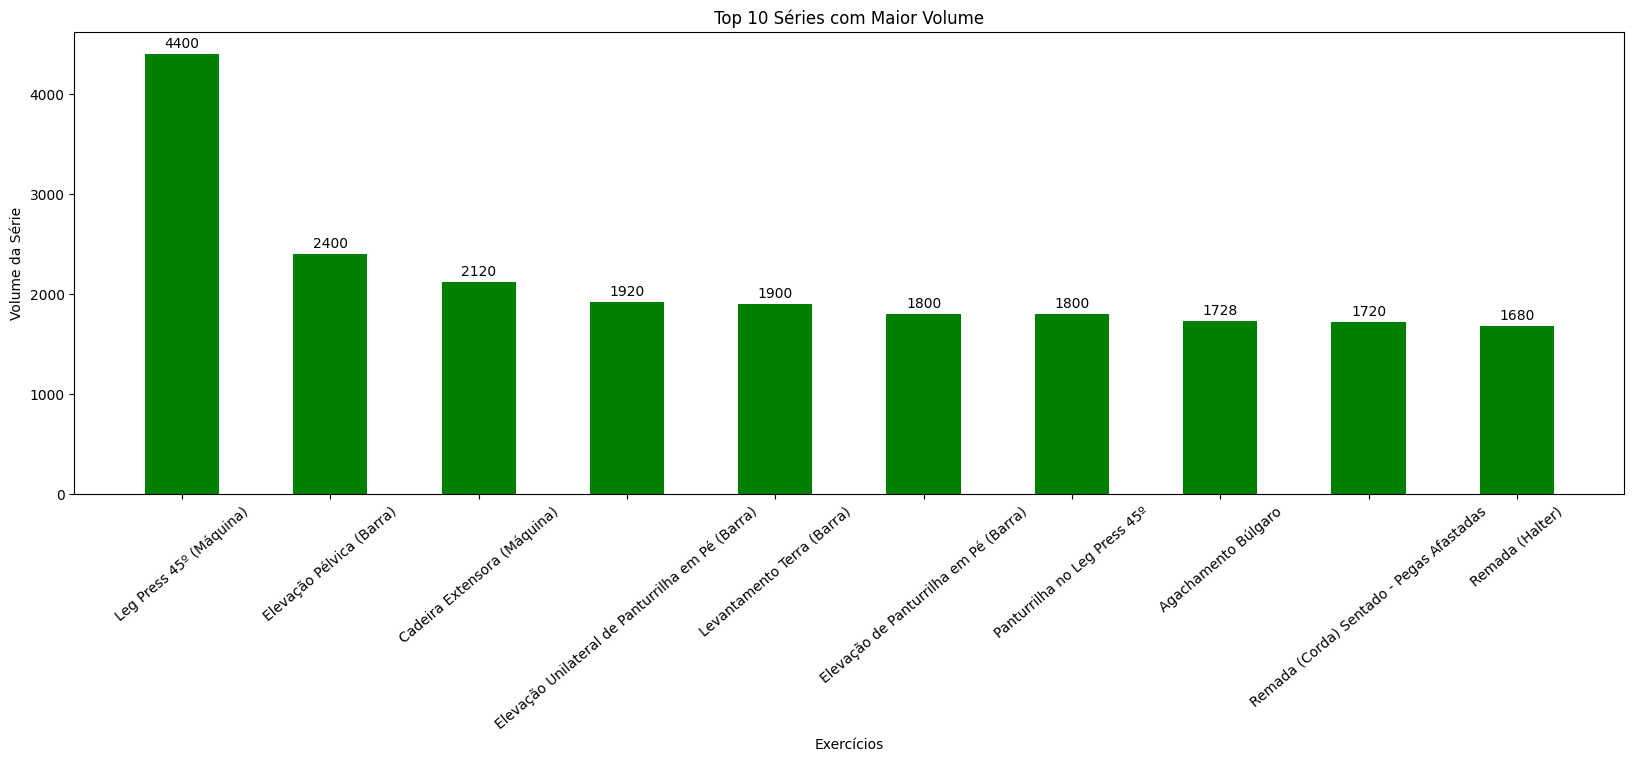

In [160]:
fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.bar(x, y, color='green', width=0.5)
ax.bar_label(meugrafico, padding=3)
ax.set_xlabel('Exercícios')
ax.set_ylabel('Volume da Série')
ax.set_title('Top 10 Séries com Maior Volume')
plt.xticks(rotation=40)
plt.show()

#### Conclusão
Após ser criado nossa tabela auxliar, para otimizar nossa consulta e resultados, chegamos aos resultados acima. Os exercicíos que se destacam em volume de série são exercicíos para grupos musculares inferiores, como pernas e gluteos, pois por se tratar de um grupo muscular maior, se destaca em carga e repetições!!

---

## Top 10 exercicio com melhores cargas de serie

In [161]:
top10_kg = tabela_auxiliar.nlargest(10, 'weight_kg')
print(top10_kg['weight_kg'])

id_exercise
32    470.0
40    300.0
35    275.0
3     240.0
20    240.0
21    240.0
36    235.0
5     230.0
22    200.0
34    200.0
Name: weight_kg, dtype: float64


In [162]:
y = top10_kg['weight_kg']
x = top10_kg['exercise_title']
print(x)

id_exercise
32                             Leg Press 45º (Máquina)
40                        Panturrilha no Leg Press 45º
35                          Levantamento Terra (Barra)
3                                  Agachamento (Barra)
20                            Elevação Pélvica (Barra)
21    Elevação Unilateral de Panturrilha em Pé (Barra)
36                             Levantamento Terra Sumô
5                        Agachamento com Banco (Barra)
22               Elevação de Panturrilha em Pé (Barra)
34                Levantamento Terra (Barra Hexagonal)
Name: exercise_title, dtype: object


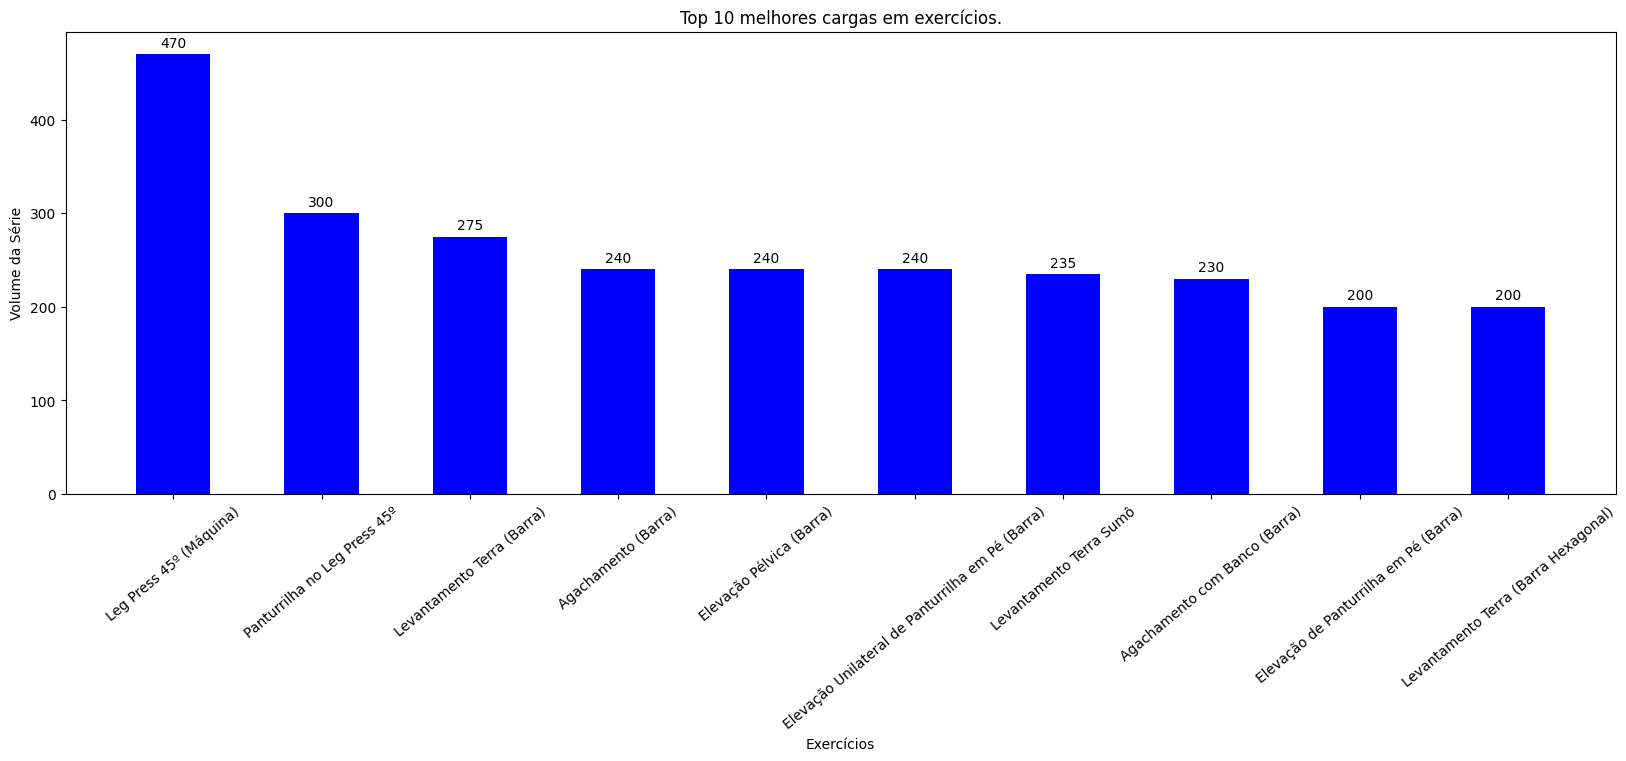

In [163]:
fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.bar(x, y, color='blue', width=0.5)
ax.bar_label(meugrafico, padding=3)
ax.set_xlabel('Exercícios')
ax.set_ylabel('Volume da Série')
ax.set_title('Top 10 melhores cargas em exercícios.')
plt.xticks(rotation=40)
plt.show()

## Conclusão: Análise de Cargas Máximas
A extração do Top 10 revela o Leg Press 45° como o líder isolado em volume de carga, evidenciando uma clara dominância dos exercícios de membros inferiores (lower body) no topo do nosso ranqueamento.

Um insight valioso gerado pela distribuição dos dados é a forte recorrência da marca de 240 kg, indicando um platô ou consolidação de força nessa faixa. Além disso, a análise levanta uma oportunidade de progressão futura: a Elevação Pélvica atingiu esse mesmo patamar de carga, porém sua repetição máxima (1RM) ainda não foi oficialmente testada, sugerindo que o limite real de força nesse movimento pode ser ainda maior!

---

## Evolução dos Movimentos Principais (Powerlifting)

- Agachamento (Squat)
- Supino (Bench Press)
- Levantamento Terra (Deadlift)

Para analisarmos a progressão de cargas ao longo do tempo (análise de série temporal), precisamos primeiro garantir a qualidade dos nossos dados. Atualmente, a coluna temporal do nosso dataset é lida apenas como texto.

Nas próximas células, realizaremos o pré-processamento dessas informações:

- Tradução e Conversão: Ajustaremos os meses do português para o inglês, possibilitando a conversão nativa para o formato datetime.
- Agregação Diária: Criaremos uma tabela auxiliar agrupando os dados por dia de treino. Isso nos permitirá extrair a carga máxima (PR diário) de cada exercício e o tempo total de treino em minutos.

Com essa estrutura pronta, seremos capazes de visualizar com precisão a evolução real da força nos três principais levantamentos do Powerlifting, além de monitorar a eficiência e a duração das sessões.

In [164]:
traducao_meses = {
    'Abr': 'Apr', 'Mai': 'May', 'Ago': 'Aug', 
    'Set': 'Sep', 'Out': 'Oct', 'Dez': 'Dec', 'Fev': 'Feb'
}

data['start_time'] = data['start_time'].replace(traducao_meses, regex=True)
data['end_time'] = data['end_time'].replace(traducao_meses, regex=True)

In [165]:
data['start_time'] = pd.to_datetime(data['start_time'], format="%d %b %Y, %H:%M")
data['end_time'] = pd.to_datetime(data['end_time'], format="%d %b %Y, %H:%M")


In [166]:
tabela_auxiliar_carga = data.groupby(by = ['start_time','end_time','id_exercise']).agg({"exercise_title":"first","weight_kg": "max",}).reset_index()
tabela_auxiliar_carga['tempo_treino'] = tabela_auxiliar_carga['end_time'] - tabela_auxiliar_carga['start_time']
tabela_auxiliar_carga['tempo_segundos'] = tabela_auxiliar_carga['tempo_treino'].dt.total_seconds()
tabela_auxiliar_carga['tempo_minutos'] =tabela_auxiliar_carga['tempo_segundos'] / 60


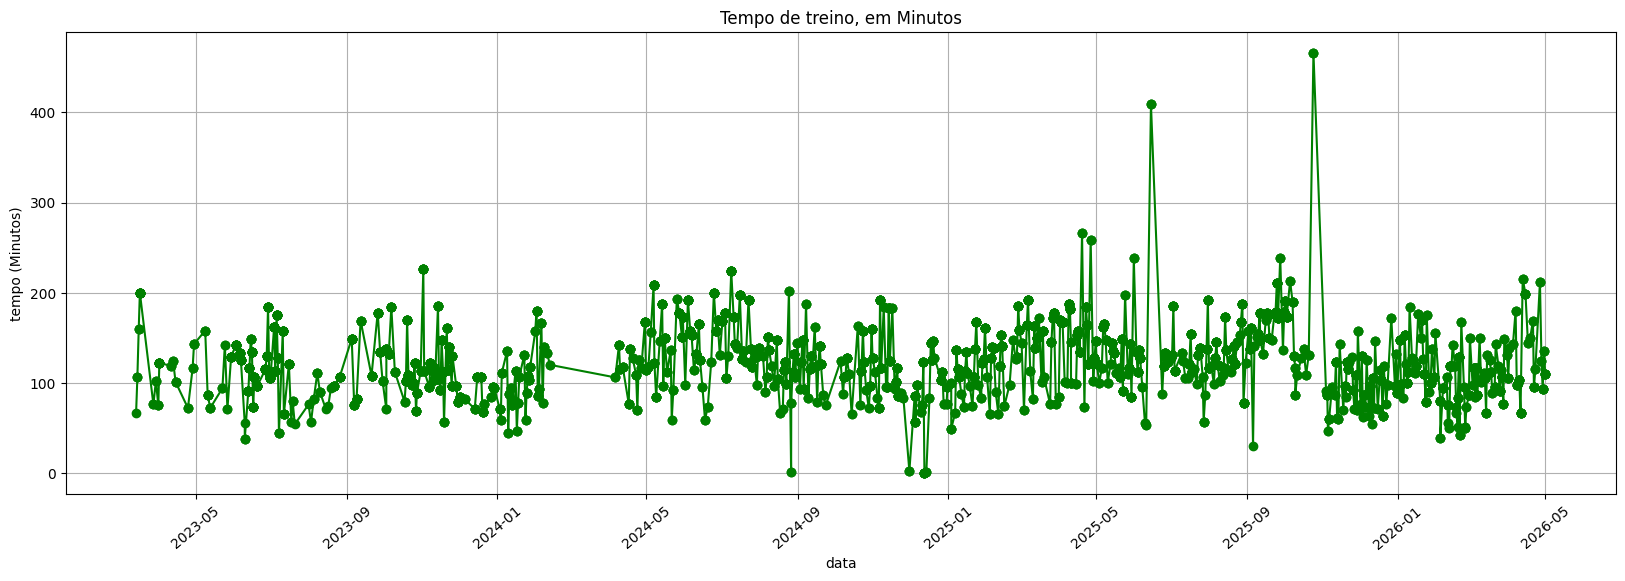

In [167]:
x = tabela_auxiliar_carga['end_time']
y = tabela_auxiliar_carga['tempo_minutos']

fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.plot(x, y, color='green', marker='o')
ax.grid(True)
ax.set_xlabel('data')
ax.set_ylabel('tempo (Minutos)')
ax.set_title('Tempo de treino, em Minutos')
plt.xticks(rotation=40)
plt.show()



In [168]:
x = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 35, 'start_time']
y = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 35, 'weight_kg']
print(y)


0       140.0
20      140.0
41      120.0
51      130.0
61      110.0
        ...  
3178    245.0
3193    250.0
3222    275.0
3234    240.0
3249    250.0
Name: weight_kg, Length: 244, dtype: float64


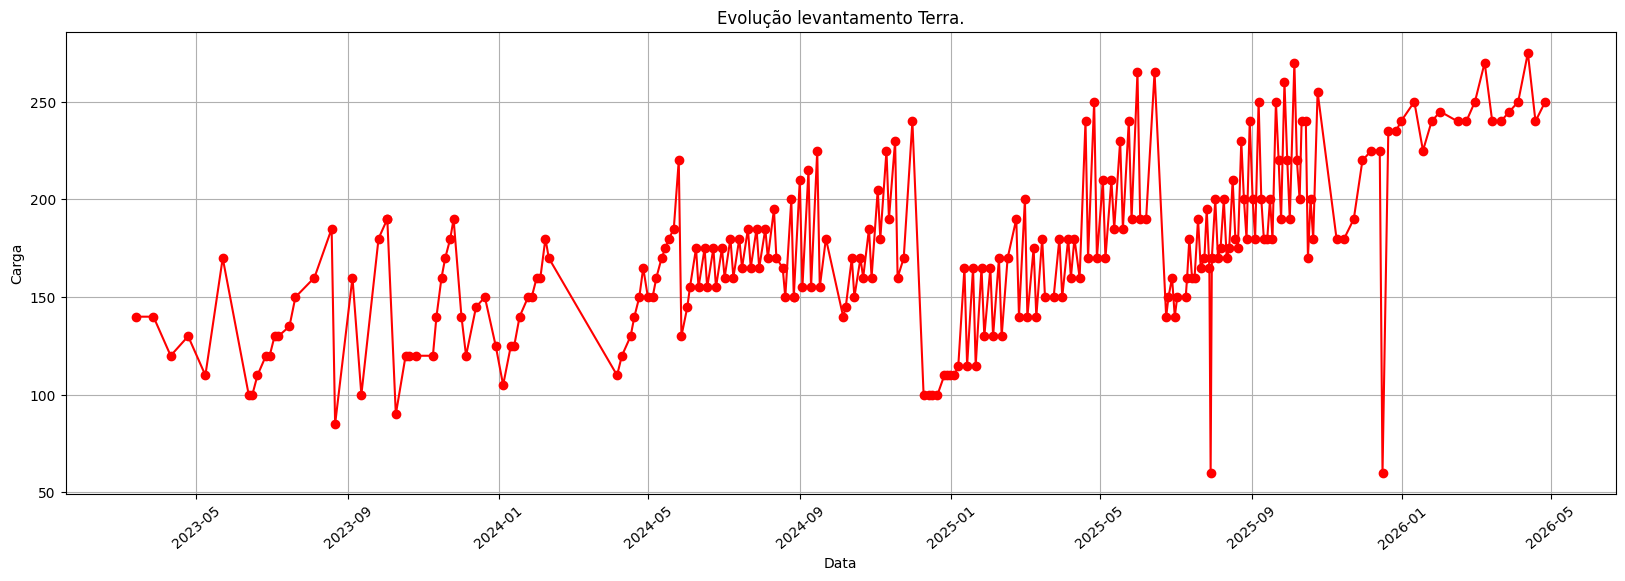

In [169]:
fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.plot(x, y, color='red', marker='o')
ax.grid(True)
ax.set_xlabel('Data')
ax.set_ylabel('Carga')
ax.set_title('Evolução levantamento Terra.')
plt.xticks(rotation=40)
plt.show()

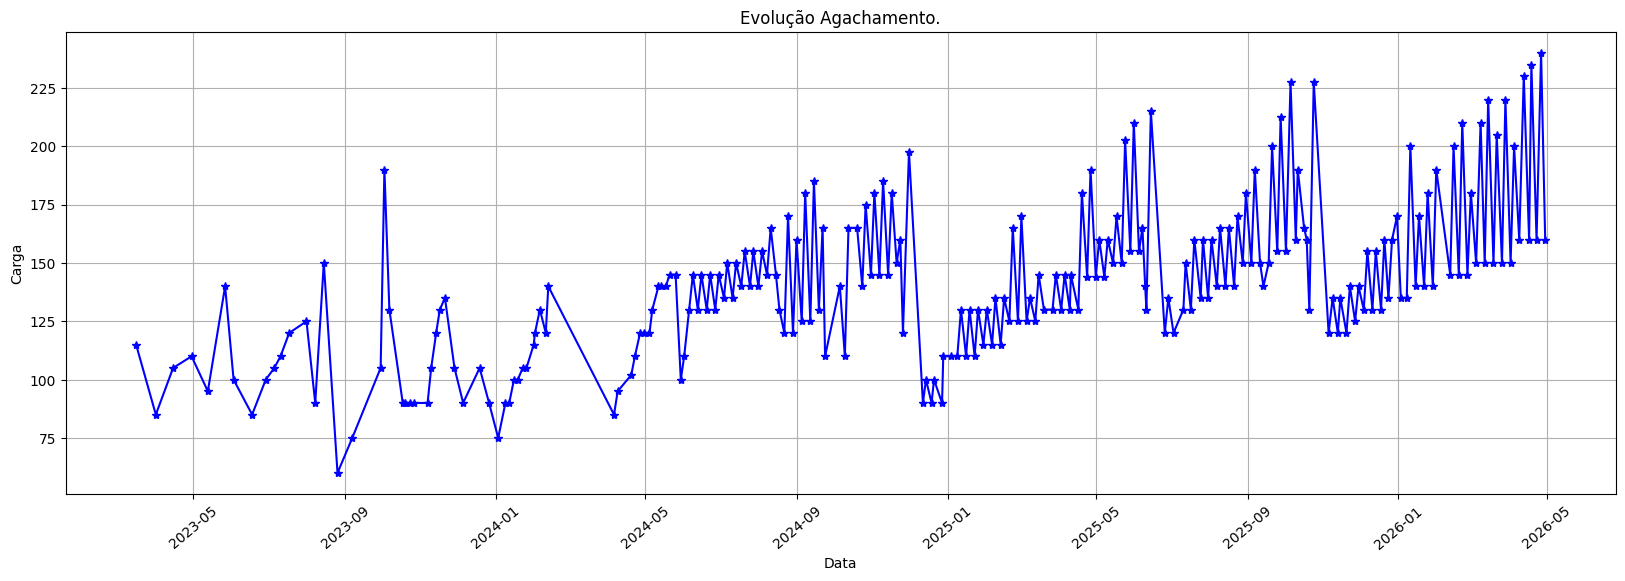

In [170]:
x = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 3, 'start_time']
y = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 3, 'weight_kg']

fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.plot(x, y, color='blue', marker='*')
ax.grid(True)
ax.set_xlabel('Data')
ax.set_ylabel('Carga')
ax.set_title('Evolução Agachamento.')
plt.xticks(rotation=40)
plt.show()

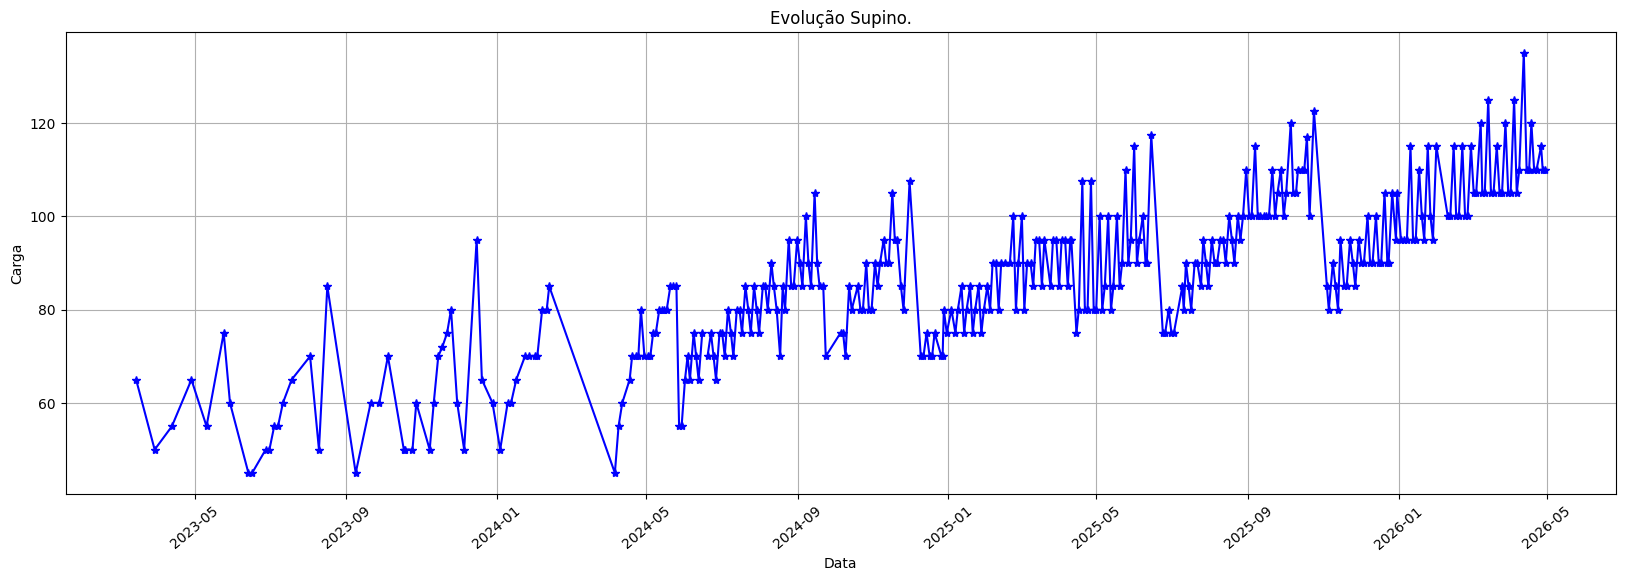

In [171]:
x = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 64, 'start_time']
y = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 64, 'weight_kg']

fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.plot(x, y, color='blue', marker='*')
ax.grid(True)
ax.set_xlabel('Data')
ax.set_ylabel('Carga')
ax.set_title('Evolução Supino.')
plt.xticks(rotation=40)
plt.show()

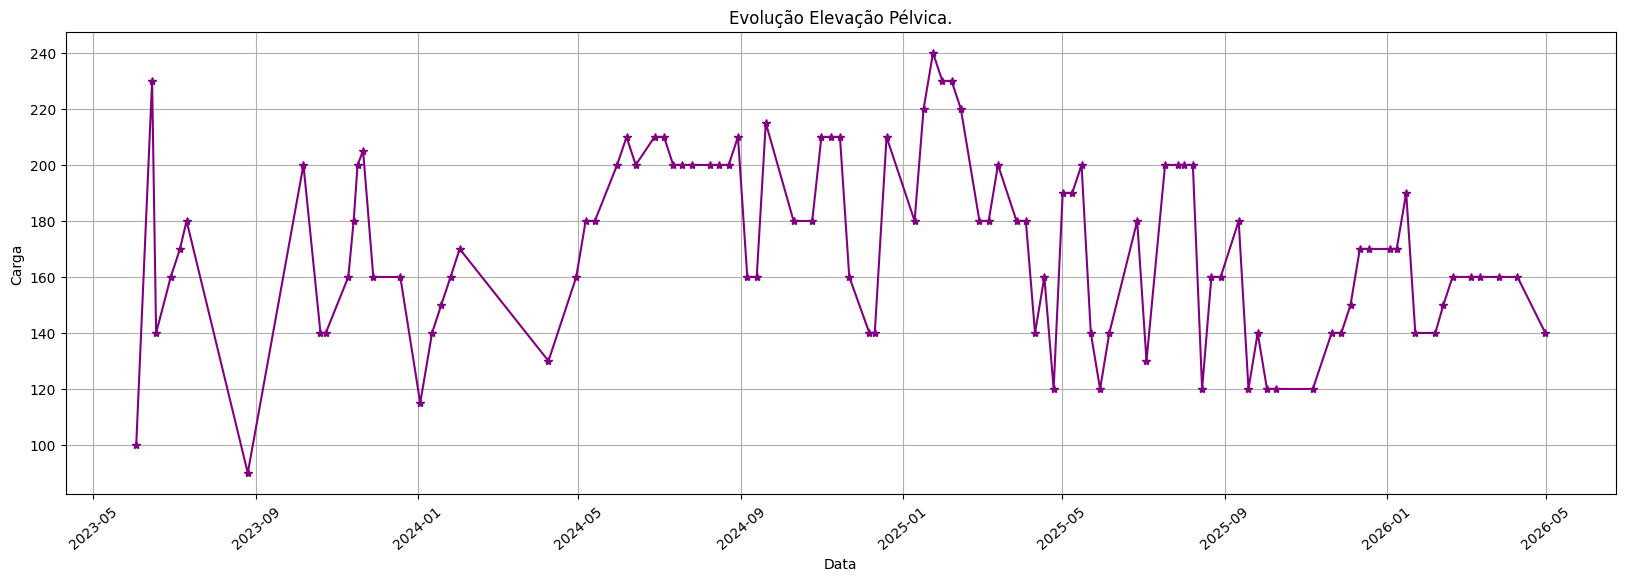

In [172]:
x = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 20, 'start_time']
y = tabela_auxiliar_carga.loc[tabela_auxiliar_carga['id_exercise'] == 20, 'weight_kg']

fig, ax = plt.subplots(figsize=(20, 6))
meugrafico = ax.plot(x, y, color='purple', marker='*')
ax.grid(True)
ax.set_xlabel('Data')
ax.set_ylabel('Carga')
ax.set_title('Evolução Elevação Pélvica.')
plt.xticks(rotation=40)
plt.show()

---

# Conclusão 📈

Após as etapas de limpeza e estruturação dos dados, nosso pipeline de tratamento incluiu:

- Conversão de Tipos: Transformação das colunas de start_time e end_time para o formato datetime.
- Engenharia de Features (Variáveis): Criação das métricas de Volume de série e tempo_treino, além da indexação com o id_exercicio.
- Tratamento de Anomalias: Limpeza manual e remoção de outliers (valores discrepantes) que distorciam a visualização.
- Agrupamento: Criação de tabelas agregadas (estruturas semelhantes a views em bancos de dados) para otimizar a geração dos gráficos.

Com os dados tratados e as visualizações geradas, transformamos registros isolados em inteligência. É possível observar claramente a linha de evolução das cargas ao longo do tempo e identificar padrões comportamentais — com destaque para a nítida quebra e aceleração de performance no momento em que iniciei o acompanhamento com um treinador profissional. Por fim, a aplicação de conceitos de agrupamento e agregação garantiu consultas otimizadas e uma análise de dados muito mais robusta e precisa.